In [13]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
import seaborn as sns

### Read the input file 'Diabetes.csv' using Pandas and check it's column names(1 Marks)

In [3]:
df = pd.read_csv("diabetes.csv")

In [ ]:
# Eye ball the imported dataset

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null int64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [7]:
df["Glucose"].replace(0,df["Glucose"].median(),inplace=True)
df["BloodPressure"].replace(0,df["BloodPressure"].median(),inplace=True)
df["SkinThickness"].replace(0,df["SkinThickness"].median(),inplace=True)
df["Insulin"].replace(0,df["Insulin"].median(),inplace=True)
df["BMI"].replace(0,df["BMI"].median(),inplace=True)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,27.334635,9.229014,7.000,23.00000,23.0000,32.00000,99.00
Insulin,768.0,94.652344,105.547598,14.000,30.50000,31.2500,127.25000,846.00
BMI,768.0,32.450911,6.875366,18.200,27.50000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Check dimension of dataset

In [10]:
df.shape

(768, 9)

### Check distribution of dependent variable, Outcome and plot it (1 Marks)

Text(0.5, 1, 'Dependant var - (Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI, DiabetesPedigreeFunction,Age) and Outcome Var')

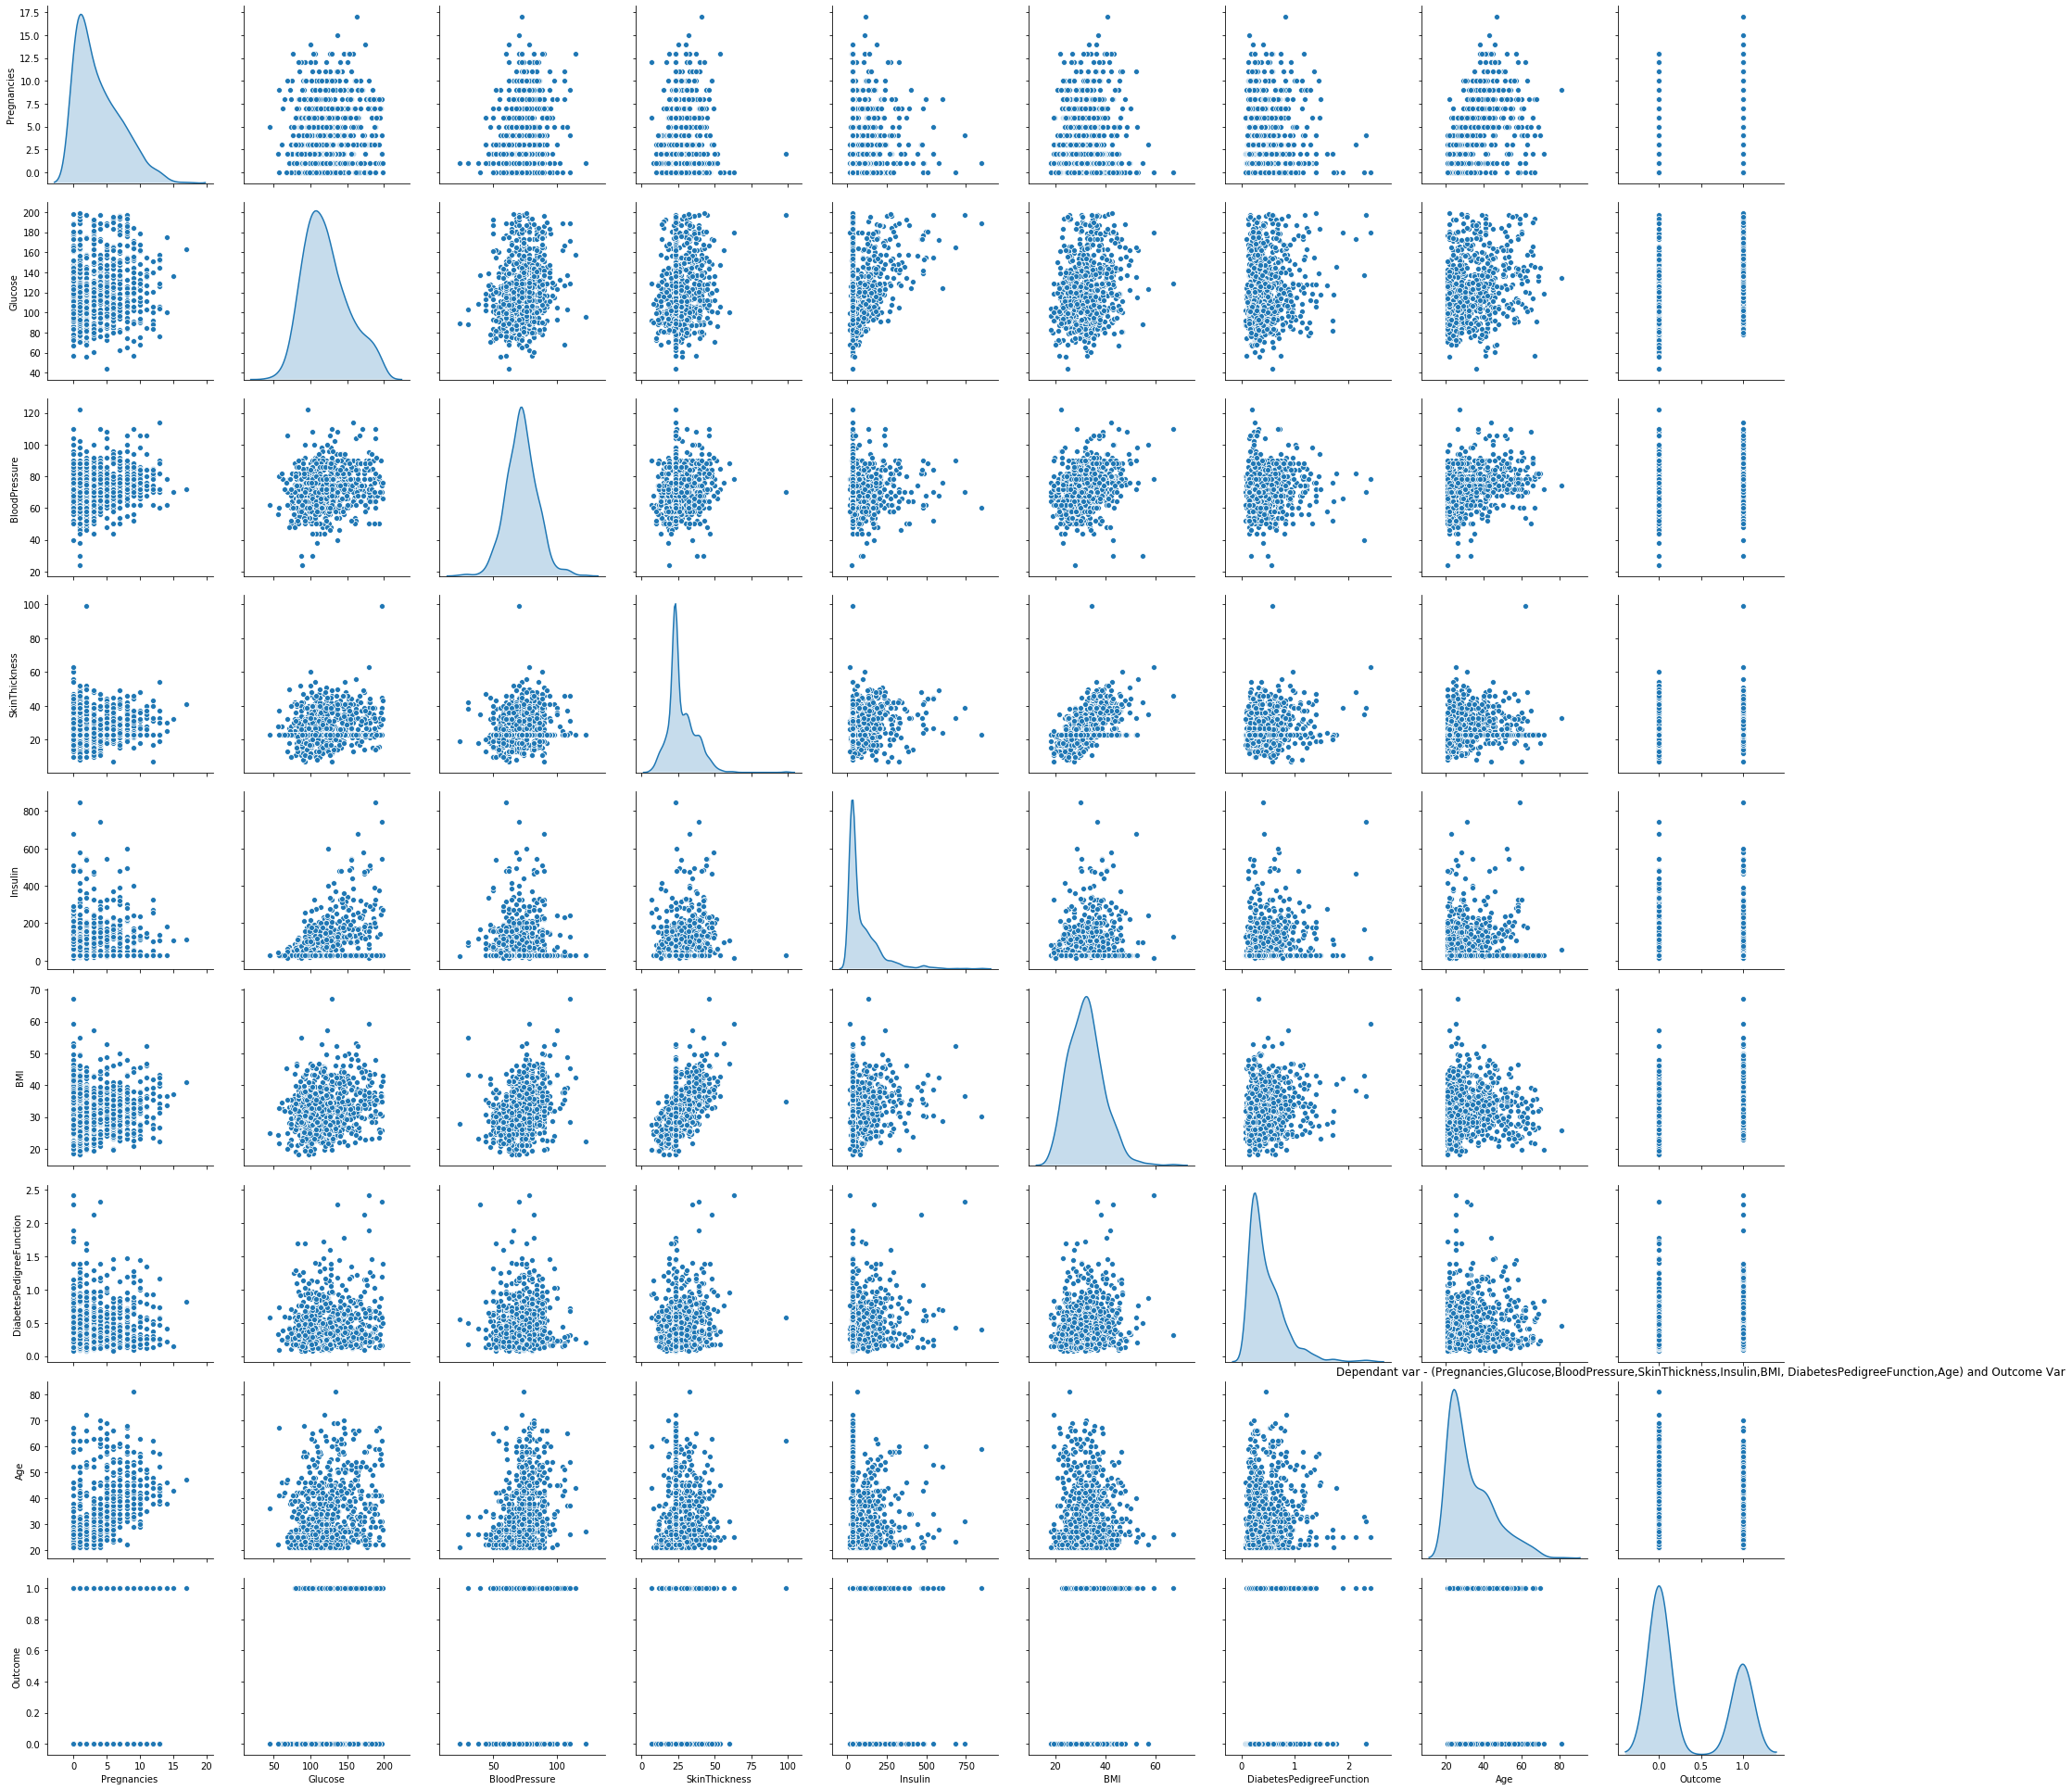

In [17]:
sns.pairplot(df, diag_kind='kde', size=3) 
plt.title('Dependant var - (Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI, DiabetesPedigreeFunction,Age) and Outcome Var')

Text(0.5, 1, 'Correlation Matrix')

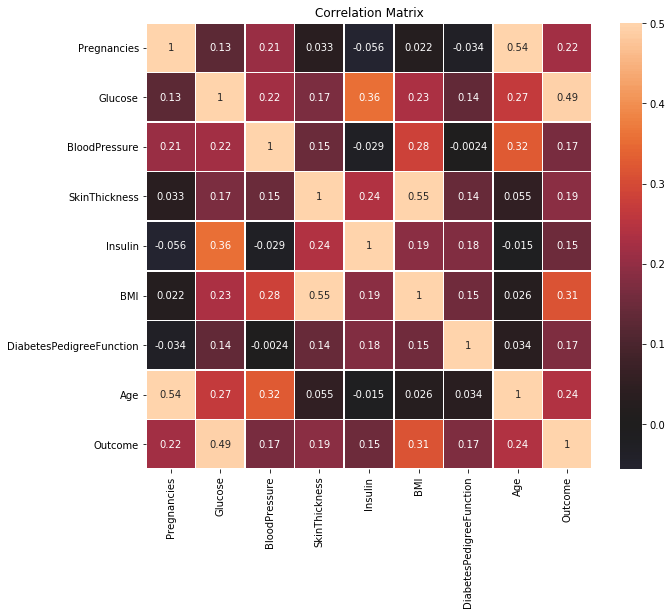

In [14]:
corr = df.corr()
plt.figure(figsize=(10, 10))
sns.heatmap(corr,annot=True, xticklabels=corr.columns.values, yticklabels=corr.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Correlation Matrix')

In [44]:
df.groupby(["Outcome"]).count()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,500,500,500,500,500,500,500,500
1,268,268,268,268,268,268,268,268


(array([500.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 268.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <a list of 20 Patch objects>)

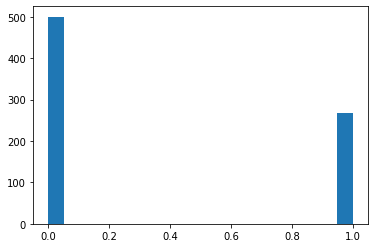

In [47]:
plt.hist(df["Outcome"], bins=20)

### Out of  768 data points, 500 are labeled as 0 and 268 as 1.
### Outcome 0 means No diabetes, outcome 1 means diabetes

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
Pregnancies                 768 non-null int64
Glucose                     768 non-null int64
BloodPressure               768 non-null int64
SkinThickness               768 non-null int64
Insulin                     768 non-null float64
BMI                         768 non-null float64
DiabetesPedigreeFunction    768 non-null float64
Age                         768 non-null int64
Outcome                     768 non-null int64
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


In [ ]:
# Check data types and info of dataset

### Check data distribution using summary statistics and provide your findings(2 Marks)

In [49]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,27.334635,94.652344,32.450911,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,9.229014,105.547598,6.875366,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,23.000000,30.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,31.250000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Do correlation analysis and bivariate viualization with Insights(1 Marks)

In [50]:
corr = df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.032568,-0.055697,0.021546,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.172143,0.357573,0.231400,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.147809,-0.028721,0.281132,-0.002378,0.324915,0.165723
SkinThickness,0.032568,0.172143,0.147809,1.000000,0.238188,0.546951,0.142977,0.054514,0.189065
Insulin,-0.055697,0.357573,-0.028721,0.238188,1.000000,0.189022,0.178029,-0.015413,0.148457
BMI,0.021546,0.231400,0.281132,0.546951,0.189022,1.000000,0.153506,0.025744,0.312249
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.142977,0.178029,0.153506,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.054514,-0.015413,0.025744,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.189065,0.148457,0.312249,0.173844,0.238356,1.000000


Text(0.5, 1, 'Correlation Matrix')

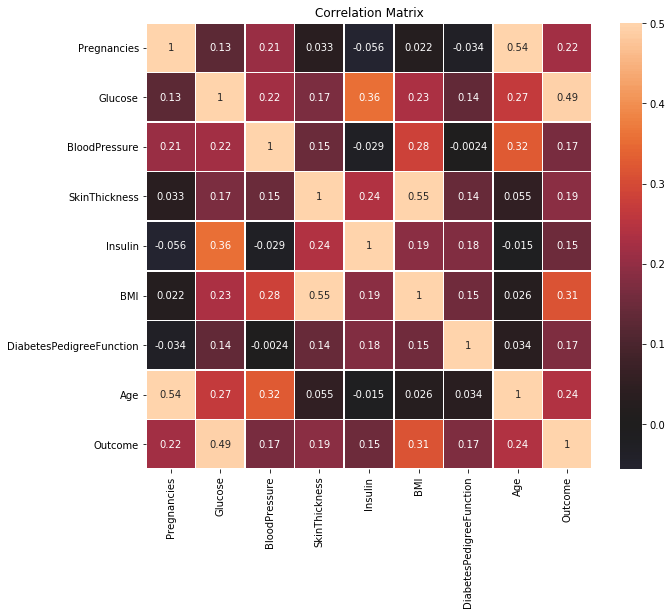

In [51]:

plt.figure(figsize=(10, 10))
sns.heatmap(corr,annot=True, xticklabels=corr.columns.values, yticklabels=corr.columns.values, vmax=.5, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Correlation Matrix')

#### Do train and test split with stratify sampling on Outcome variable to maintain the distribution of dependent variable(1 Marks)

In [52]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=10)

### Train Support Vector Machine Model(1 Marks)

In [ ]:
# use from sklearn.svm import SVC

In [54]:
from sklearn.svm import SVC

In [55]:
model = SVC()

In [56]:
model.fit(X_train, y_train)

/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='rbf', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

In [57]:
model.score(X_train, y_train)

1.0

In [58]:
model.score(X_test, y_test)

0.6377952755905512

In [15]:
# your insights
# C = 1 , Kernel = Rbf ,Model score = 0.649

In [59]:
ker = ['rbf','linear']
for k in ker:
    model = SVC(kernel = k)
    model.fit(X_train, y_train)
    print(k,'-','train -',model.score(X_train, y_train))
    print(k,'-','test -',model.score(X_test, y_test))

/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


rbf - train - 1.0
rbf - test - 0.6377952755905512
linear - train - 0.7782101167315175
linear - test - 0.7480314960629921


### Scale the data points using MinMaxScaler ( 1 Marks)

In [60]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_X=scaler.fit_transform(X)
scaled_X

array([[0.35294118, 0.67096774, 0.48979592, ..., 0.31492843, 0.23441503,
        0.48333333],
       [0.05882353, 0.26451613, 0.42857143, ..., 0.17177914, 0.11656704,
        0.16666667],
       [0.47058824, 0.89677419, 0.40816327, ..., 0.10429448, 0.25362938,
        0.18333333],
       ...,
       [0.29411765, 0.49677419, 0.48979592, ..., 0.16359918, 0.07130658,
        0.15      ],
       [0.05882353, 0.52903226, 0.36734694, ..., 0.24335378, 0.11571307,
        0.43333333],
       [0.05882353, 0.31612903, 0.46938776, ..., 0.24948875, 0.10119556,
        0.03333333]])

In [61]:
X_trainS, X_testS, y_trainS, y_testS = train_test_split(scaled_X, y, test_size=0.33, random_state=10)

### Fit SVM Model on Scale data and give your observation( 1 Marks)

In [63]:
ker = ['rbf','linear']
for k in ker:
    model = SVC(kernel = k)
    model.fit(X_trainS, y_trainS)
    print("using train data")
    print(k,'-',model.score(X_trainS, y_trainS))
    print("using test data")
    print(k,'-',model.score(X_testS, y_testS))

using train data
rbf - 0.7821011673151751
using test data
rbf - 0.7362204724409449
using train data
linear - 0.7782101167315175
using test data
linear - 0.7401574803149606


/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


Try improving the model accuracy using C=1000 (1 Mark

In [67]:
ker = ['rbf','linear']
for k in ker:
    model = SVC(C=1000,kernel = k)
    model.fit(X_train, y_train)
    print(k,'-',model.score(X_train, y_train))
    print(k,'-',model.score(X_test, y_test))

/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


rbf - 1.0
rbf - 0.6377952755905512
linear - 0.7704280155642024
linear - 0.7519685039370079


In [68]:
ker = ['rbf','linear']
gamma = [10,100,500,1000,2000,5000]
result = pd.DataFrame()
for k in ker:
    for g in gamma:
        model = SVC(C=g,kernel = k)
        model.fit(X_trainS, y_trainS)
        result = result.append({'kernel':k,'C':g,'accuracy':model.score(X_testS, y_testS)},ignore_index=True) 
        

/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/Applications/anaconda3/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)
/Applications/anaconda3/lib/python3.6/site-packages/

In [69]:
result

,C,accuracy,kernel
0,10.0,0.751969,rbf
1,100.0,0.751969,rbf
2,500.0,0.759843,rbf
3,1000.0,0.767717,rbf
4,2000.0,0.767717,rbf
5,5000.0,0.763780,rbf
6,10.0,0.744094,linear
7,100.0,0.748031,linear
8,500.0,0.744094,linear
9,1000.0,0.744094,linear


#we can try increasing either C or gamma to fit a more complex model.

### Here, increasing C allows us to improve the model, resulting in ??? accuracy.
### Let's try to explore different Kernel and C (Bonus for practice)

In [70]:
import multiprocessing 
from sklearn.model_selection import GridSearchCV

In [71]:
 param_grid = [    {        
     'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],        
     'C': [ 0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5, 3.0 ]    } ]

In [72]:
gs = GridSearchCV(estimator=SVC(), param_grid=param_grid,scoring='accuracy', cv=10, n_jobs=multiprocessing.cpu_count())

In [73]:
gs.fit(X_trainS, y_trainS) 

/Applications/anaconda3/lib/python3.6/site-packages/sklearn/model_selection/_search.py:813: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


GridSearchCV(cv=10, error_score='raise-deprecating',
             estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='auto_deprecated', kernel='rbf', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='warn', n_jobs=4,
             param_grid=[{'C': [0.1, 0.2, 0.4, 0.5, 1.0, 1.5, 1.8, 2.0, 2.5,
                                3.0],
                          'kernel': ['linear', 'rbf', 'poly', 'sigmoid']}],
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='accuracy', verbose=0)

In [74]:
gs.best_estimator_

SVC(C=0.2, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto_deprecated',
    kernel='linear', max_iter=-1, probability=False, random_state=None,
    shrinking=True, tol=0.001, verbose=False)

In [75]:
gs.best_score_ 

0.7801556420233463